In [118]:
# Librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [119]:
#Carga del archivo Excel en un DataFrame de pandas

df_financiero = pd.read_excel(FILE_PATH)

df_financiero.head()


,año,trimestre,fecha,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
0,2025,1,2025-03-31,5404642,1382773,371148,93147
1,2025,2,2025-06-30,5208469,1335783,452242,146865
2,2025,3,2025-09-30,5228905,1312056,448017,142905
3,2025,4,2025-12-31,6166344,1612428,670615,209191
4,2024,1,2024-03-31,5275139,1321953,302113,-37863


In [120]:
print(f"Filas: {df_financiero.shape[0]}")
print(f"Columnas: {df_financiero.shape[1]}")

Filas: 24
Columnas: 7


In [121]:
df_financiero.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   año                24 non-null     int64         
 1   trimestre          24 non-null     int64         
 2   fecha              24 non-null     datetime64[us]
 3   ingresos           24 non-null     int64         
 4   utilidad_bruta     24 non-null     int64         
 5   ebitda_recurrente  24 non-null     int64         
 6   resultado_neto     24 non-null     int64         
dtypes: datetime64[us](1), int64(6)
memory usage: 1.4 KB


In [122]:
df_financiero.describe()

,año,trimestre,fecha,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
count,24.000000,24.00000,24,2.400000e+01,2.400000e+01,24.000000,24.000000
mean,2022.500000,2.50000,2023-02-14 02:00:00,4.928702e+06,1.259672e+06,403105.875000,65729.875000
min,2020.000000,1.00000,2020-03-31 00:00:00,3.649939e+06,9.018710e+05,249457.000000,-77668.000000
25%,2021.000000,1.75000,2021-09-07 00:00:00,4.299724e+06,1.121965e+06,323205.250000,8044.250000
50%,2022.500000,2.50000,2023-02-14 00:00:00,5.125298e+06,1.301692e+06,371032.500000,57039.000000
75%,2024.000000,3.25000,2024-07-23 00:00:00,5.307515e+06,1.376063e+06,454288.750000,130462.500000
max,2025.000000,4.00000,2025-12-31 00:00:00,6.288024e+06,1.624970e+06,670615.000000,212665.000000
std,1.744557,1.14208,NaN,7.832749e+05,2.072294e+05,113896.654294,79112.152678


In [123]:
# Revisión de nulos

print(f"Valores nulos en cada columna:")
print(df_financiero.isnull().sum())

Valores nulos en cada columna:
año                  0
trimestre            0
fecha                0
ingresos             0
utilidad_bruta       0
ebitda_recurrente    0
resultado_neto       0
dtype: int64


In [124]:
# Revisión de duplicados

print(f"Filas duplicadas: {df_financiero.duplicated().sum()}")


Filas duplicadas: 0


In [125]:
# Verificación de cobertura temporal de los datos

print(f"Año inicial: {df_financiero['año'].min()}")
print(f"Año final: {df_financiero['año'].max()}")
print(f"Número de años: {df_financiero['año'].nunique()}")
print(f"Número de trimestres: {df_financiero['trimestre'].nunique()}")

Año inicial: 2020
Año final: 2025
Número de años: 6
Número de trimestres: 4


In [126]:
# Comprobación de los 4 trimestres por año

cobertura_trimestres =(
df_financiero
.groupby('año')['trimestre']
.agg(["count", "min", "max"])
)
print(f"Cobertura de trimestres por año:")
print(cobertura_trimestres)

Cobertura de trimestres por año:
      count  min  max
año                  
2020      4    1    4
2021      4    1    4
2022      4    1    4
2023      4    1    4
2024      4    1    4
2025      4    1    4


## 4. Detección de valores atípicos

Se analiza la distribución de las principales variables financieras para identificar
valores extremos que puedan afectar posteriormente el análisis exploratorio y los
modelos de pronóstico.

In [127]:
variables_financieras = [
    'ingresos',
    'utilidad_bruta',
    'ebitda_recurrente',
    'resultado_neto'
]

df_financiero[variables_financieras].describe().T

,count,mean,std,min,25%,50%,75%,max
ingresos,24.0,4.928702e+06,783274.911880,3649939.0,4299724.00,5125298.5,5307514.75,6288024.0
utilidad_bruta,24.0,1.259672e+06,207229.360380,901871.0,1121965.25,1301692.5,1376062.75,1624970.0
ebitda_recurrente,24.0,4.031059e+05,113896.654294,249457.0,323205.25,371032.5,454288.75,670615.0
resultado_neto,24.0,6.572988e+04,79112.152678,-77668.0,8044.25,57039.0,130462.50,212665.0


In [128]:
# Análisis del rango intercuartílico (IQR) para detectar valores atípicos

for variable in variables_financieras:
    Q1 = df_financiero[variable].quantile(0.25)
    Q3 = df_financiero[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_financiero[
        (df_financiero[variable] < limite_inferior) |
        (df_financiero[variable] > limite_superior)
    ]

    print(f"\n{variable}")
    print(f"Límite inferior: {limite_inferior:,.0f}")
    print(f"Límite superior: {limite_superior:,.0f}")
    print(f"Posibles outliers: {len(outliers)}")


ingresos
Límite inferior: 2,788,038
Límite superior: 6,819,201
Posibles outliers: 0

utilidad_bruta
Límite inferior: 740,819
Límite superior: 1,757,209
Posibles outliers: 0

ebitda_recurrente
Límite inferior: 126,580
Límite superior: 650,914
Posibles outliers: 1

resultado_neto
Límite inferior: -175,583
Límite superior: 314,090
Posibles outliers: 0


In [129]:
# Identificación del posible outlier en la variable "ebitda_recurrente"

Q1 = df_financiero["ebitda_recurrente"].quantile(0.25)
Q3 = df_financiero["ebitda_recurrente"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ebitda = df_financiero[
    (df_financiero["ebitda_recurrente"] < limite_inferior) |
    (df_financiero["ebitda_recurrente"] > limite_superior)
]

outliers_ebitda[
    ["año", "trimestre", "fecha", "ingresos",
     "utilidad_bruta", "ebitda_recurrente", "resultado_neto"]
]

,año,trimestre,fecha,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
3,2025,4,2025-12-31,6166344,1612428,670615,209191


In [130]:
# Comparación temporal

df_financiero[
    (df_financiero["año"] == 2025) &
    (df_financiero["trimestre"].isin([1, 2, 3, 4]))
][[
    "año",
    "trimestre",
    "ingresos",
    "utilidad_bruta",
    "ebitda_recurrente",
    "resultado_neto"

]]

,año,trimestre,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
0,2025,1,5404642,1382773,371148,93147
1,2025,2,5208469,1335783,452242,146865
2,2025,3,5228905,1312056,448017,142905
3,2025,4,6166344,1612428,670615,209191


In [131]:
# Comparación con el trimestre 4 de cada año

df_financiero[
    (df_financiero["trimestre"] == 4)
][[
    "año",
    "trimestre",
    "ingresos",
    "utilidad_bruta",
    "ebitda_recurrente",
    "resultado_neto"
]]

,año,trimestre,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
3,2025,4,6166344,1612428,670615,209191
7,2024,4,6288024,1624970,638210,146117
11,2023,4,5415336,1373826,527034,118749
15,2022,4,6196646,1574532,537323,-77668
19,2021,4,5242669,1395683,568638,212665
23,2020,4,4345013,1142061,460429,144284


### Análisis del posible outlier

Al detectar un posible outlier en el ebitda recurrente correspondiente al trimestre 4 del 2025 se procede a comparar 
este valor con los tres trimestres restantes del mismo año, en donde se observa que su valor es mucho mayor,
sin embargo al realizar la comparación con el trimestre 4 de los años 2020 a 2024, se puede evidenciar que aunque es el mayor
de todos se presenta un patron de incremento en estos trimestres, lo cual nos confirma que es un patron de comportamiento y no 
un dato erroneo.


## 5. Análisis de evolución temporal

In [132]:
df_financiero = df_financiero.sort_values("fecha").reset_index(drop=True)

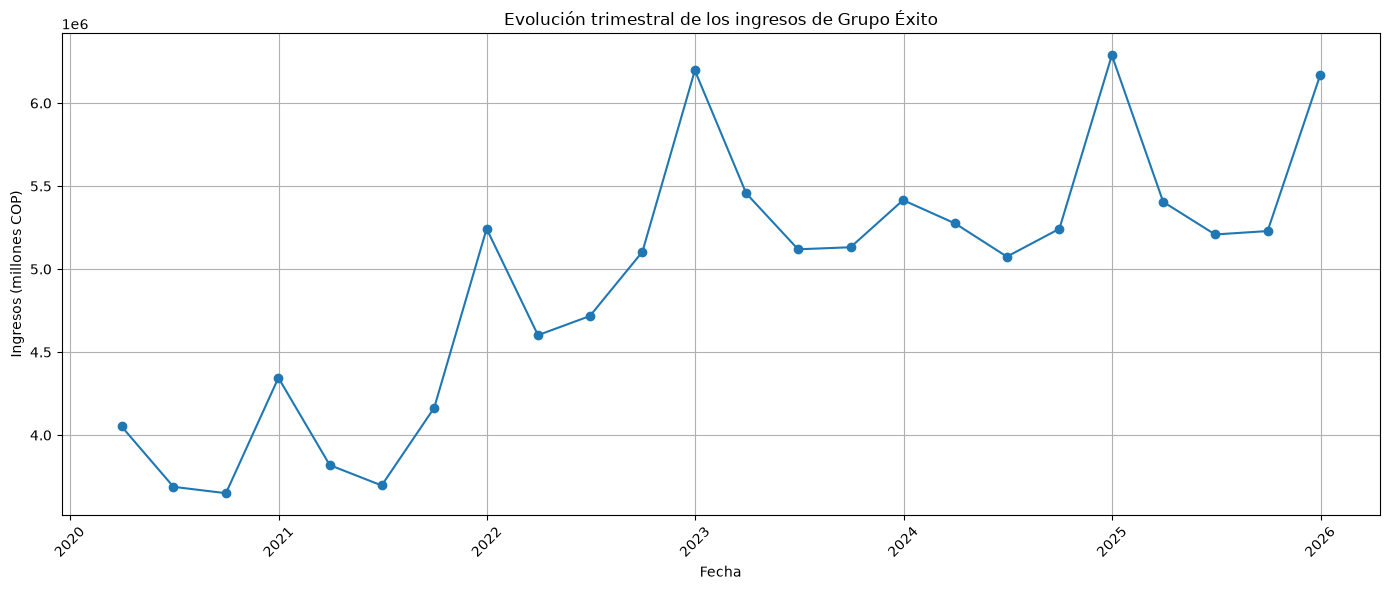

In [133]:
# Ingresos trimestrales de Grupo Éxito

plt.figure(figsize=(14, 6))

plt.plot(
    df_financiero["fecha"],
    df_financiero["ingresos"],
    marker="o"
)

plt.title("Evolución trimestral de los ingresos de Grupo Éxito")
plt.xlabel("Fecha")
plt.ylabel("Ingresos (millones COP)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

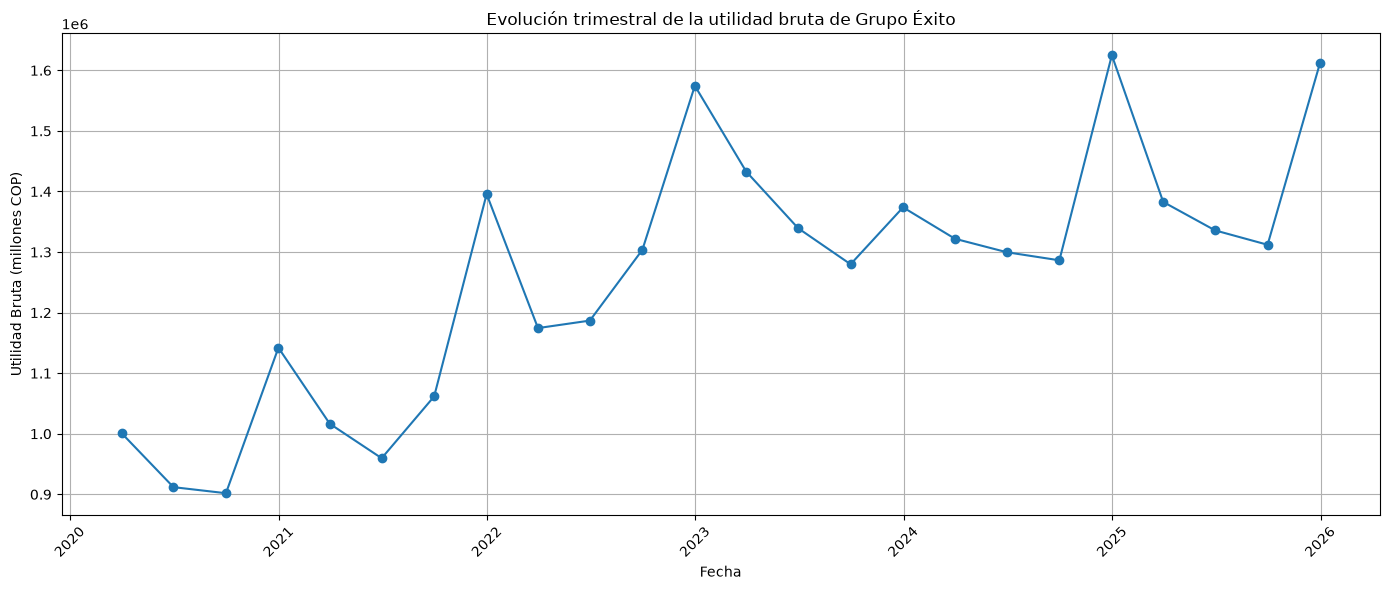

In [134]:
# Utilidad bruta trimestral de Grupo Éxito

plt.figure(figsize=(14, 6))

plt.plot(
    df_financiero["fecha"],
    df_financiero["utilidad_bruta"],
    marker="o"
)

plt.title("Evolución trimestral de la utilidad bruta de Grupo Éxito")
plt.xlabel("Fecha")
plt.ylabel("Utilidad Bruta (millones COP)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

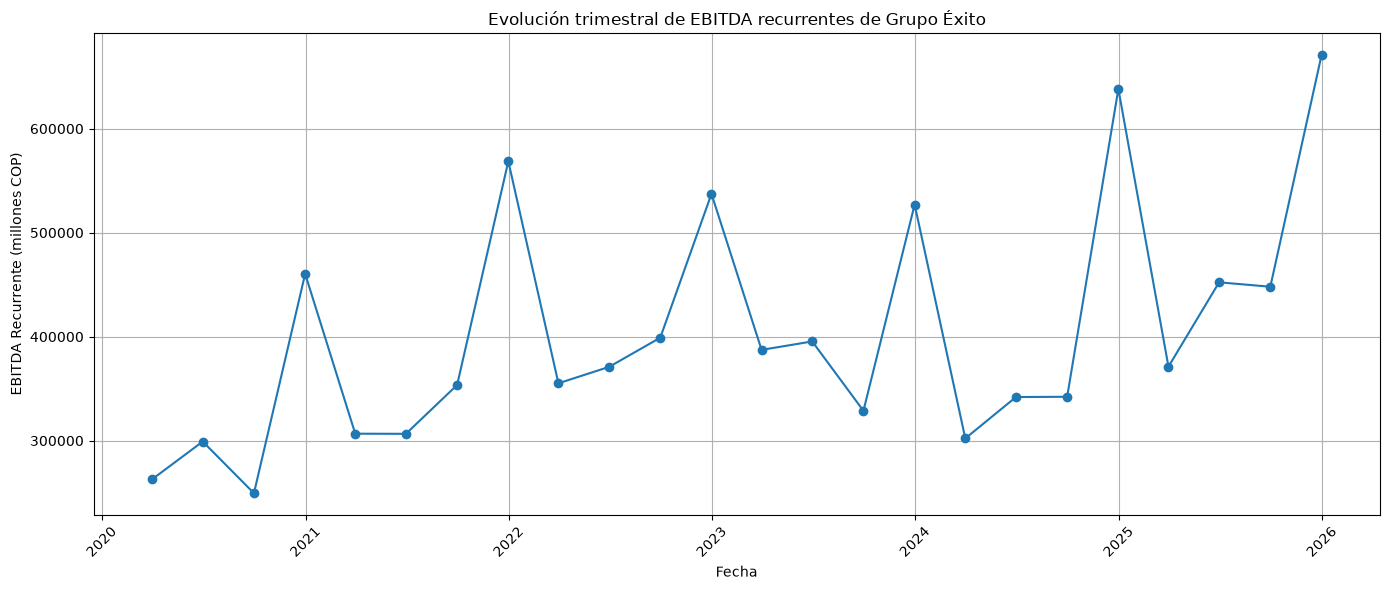

In [135]:
# EBITDA recurrente trimestral de Grupo Éxito

plt.figure(figsize=(14, 6))

plt.plot(
    df_financiero["fecha"],
    df_financiero["ebitda_recurrente"],
    marker="o"
)

plt.title("Evolución trimestral de EBITDA recurrentes de Grupo Éxito")
plt.xlabel("Fecha")
plt.ylabel("EBITDA Recurrente (millones COP)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

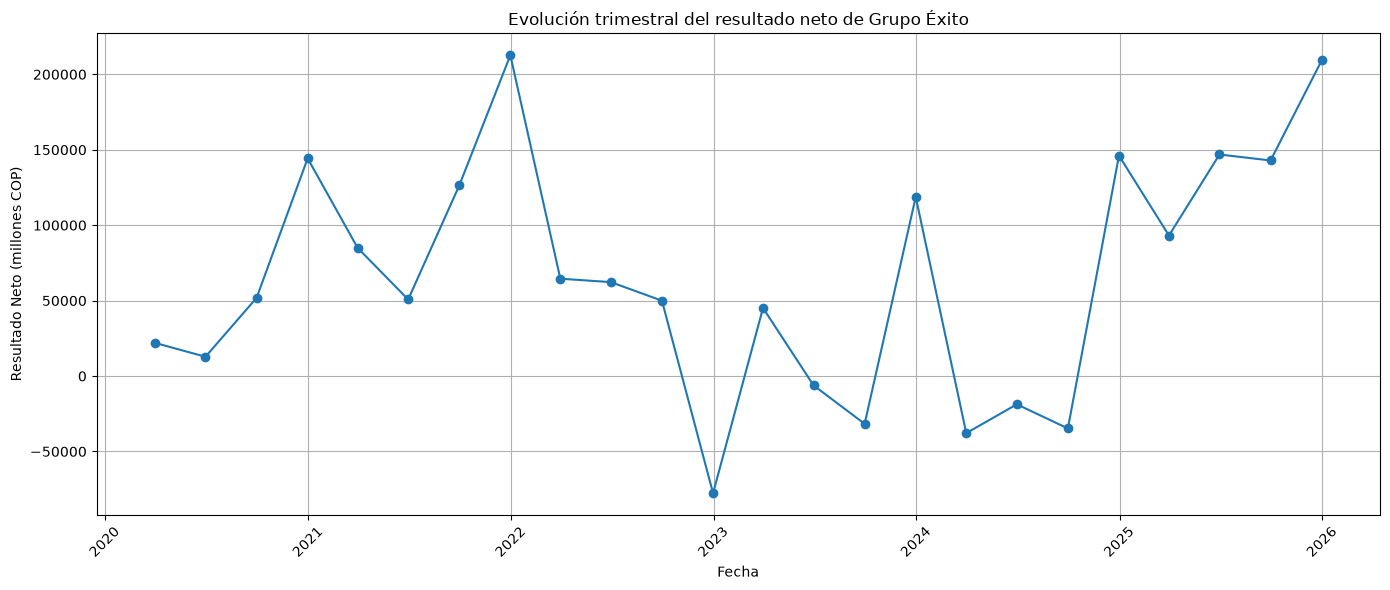

In [136]:
# Resultado neto trimestral de Grupo Éxito

plt.figure(figsize=(14, 6))

plt.plot(
    df_financiero["fecha"],
    df_financiero["resultado_neto"],
    marker="o"
)

plt.title("Evolución trimestral del resultado neto de Grupo Éxito")
plt.xlabel("Fecha")
plt.ylabel("Resultado Neto (millones COP)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()